<a href="https://colab.research.google.com/github/jacobdawson093-tech/Montgomery-County-and-Bias-Incidents-Analysis/blob/main/eda/notebooks/Data_Capstone_Project_graphs_Jacob_Dawson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url = "https://api.census.gov/data/2024/acs/acs5?get=NAME,B02001_003E&for=county:031&in=state:24"
import os
os.makedirs("graphs", exist_ok=True)

# Send request
response = requests.get(url)

# Print the raw response text to help diagnose issues if not JSON
print("API Response Text:", response.text)

# Convert to JSON
data = response.json()

african_american_population = data[1][1]
county_name = data[1][0]
print(f"African American population in {county_name}: {african_american_population}")

API Response Text: [["NAME","B02001_003E","state","county"],
["Montgomery County, Maryland","198264","24","031"]]
African American population in Montgomery County, Maryland: 198264


In [ ]:



url2 = "https://data.montgomerycountymd.gov/api/v3/views/7bhj-887p/query.json?app_token=8kUbrmGzgoxqe4z7C91iV3wmC"

response2 = requests.get(url2)

# Convert to JSON
data2 = response2.json()

if data2:
    for key in data2[2].keys():
        print(key)

    # Initialize a dictionary to store incidents per year
    incidents_per_year = {}

    # Iterate through the data to count incidents per year
    for item in data2:
        if 'incident_date' in item and item['incident_date']:
            year = item['incident_date'][:4] # Extract the first 4 characters (year)
            incidents_per_year[year] = incidents_per_year.get(year, 0) + 1

    # Print the results
    print("Total incidents per year:")
    for year, count in incidents_per_year.items():
        print(f"Year {year}: {count} incidents")
else:
    print("No data found in the response.")

:id
:version
:created_at
:updated_at
id
incident_date
district
bias_code
bias
status
no_of_victims
victim_type
no_of_suspects
unknown
Total incidents per year:
Year 2026: 44 incidents
Year 2025: 332 incidents
Year 2024: 485 incidents
Year 2023: 466 incidents
Year 2022: 160 incidents
Year 2021: 144 incidents
Year 2020: 117 incidents
Year 2019: 114 incidents
Year 2018: 93 incidents
Year 2017: 122 incidents
Year 2016: 98 incidents


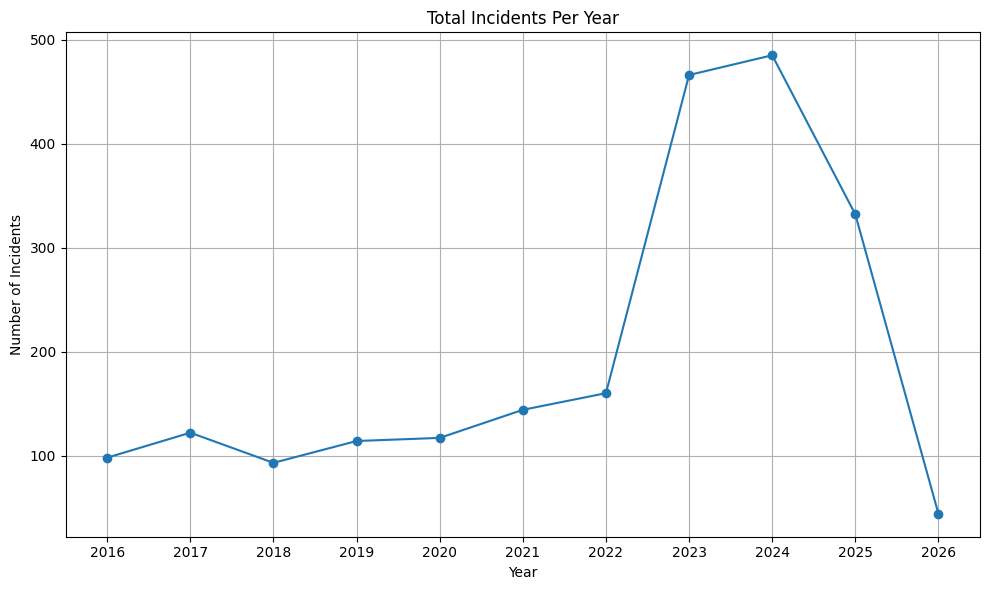

In [ ]:

incidents_series = pd.Series(incidents_per_year)

incidents_series.index = incidents_series.index.astype(int)

incidents_series = incidents_series.sort_index()

plt.figure(figsize=(10, 6))
plt.plot(incidents_series.index, incidents_series.values, marker='o', linestyle='-')
plt.title('Total Incidents Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.xticks(incidents_series.index) # Ensure all years are shown on x-axis
plt.tight_layout()
plt.savefig("graphs/Total Incidents Per Year Scatter-Line Plot.png", bbox_inches="tight")
plt.show()

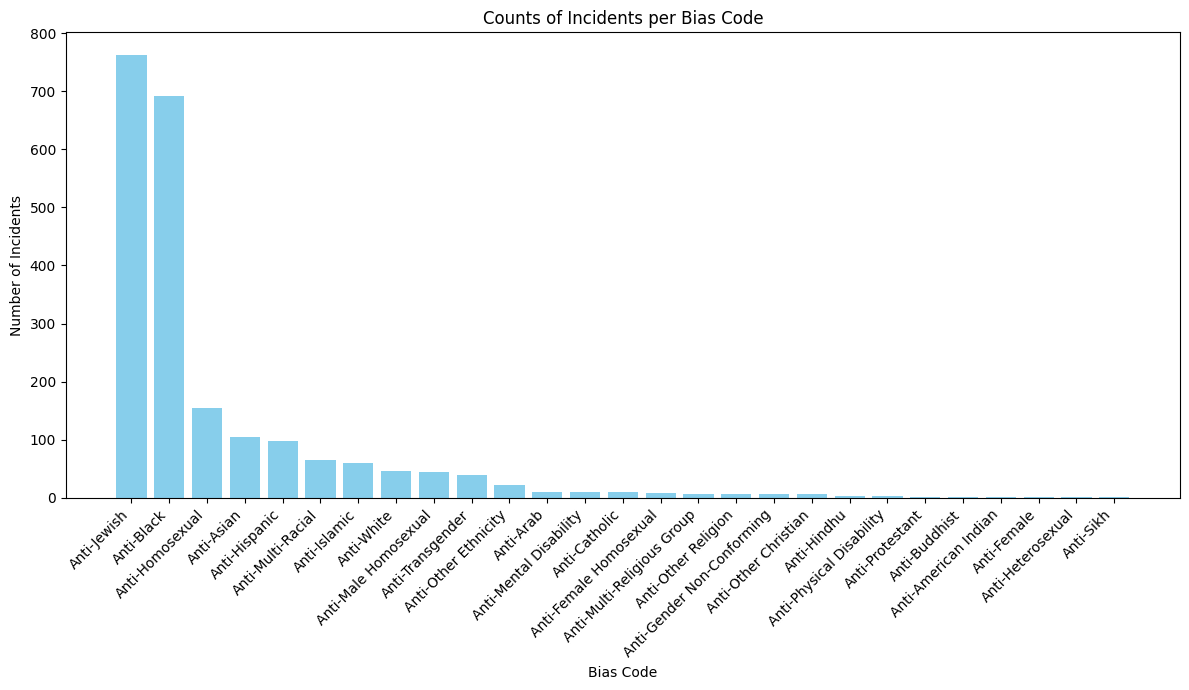

In [ ]:


# Initialize a dictionary to store counts of each bias_code
bias_code_counts = {}

# Iterate through the data to count incidents per bias_code
if data2:
    for item in data2:
        if 'bias_code' in item and item['bias_code']:
            bias_code = item['bias_code']
            bias_code_counts[bias_code] = bias_code_counts.get(bias_code, 0) + 1

    # Sort the bias codes by count for better visualization
    sorted_bias_codes = sorted(bias_code_counts.items(), key=lambda x: x[1], reverse=True)
    codes = [item[0] for item in sorted_bias_codes]
    counts = [item[1] for item in sorted_bias_codes]

    # Create the bar plot
    plt.figure(figsize=(12, 7))
    plt.bar(codes, counts, color='skyblue')
    plt.xlabel('Bias Code')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Bias Code')
    plt.xticks(rotation=45, ha='right') # Rotate labels for readability
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Race - Histogram.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count bias codes.")

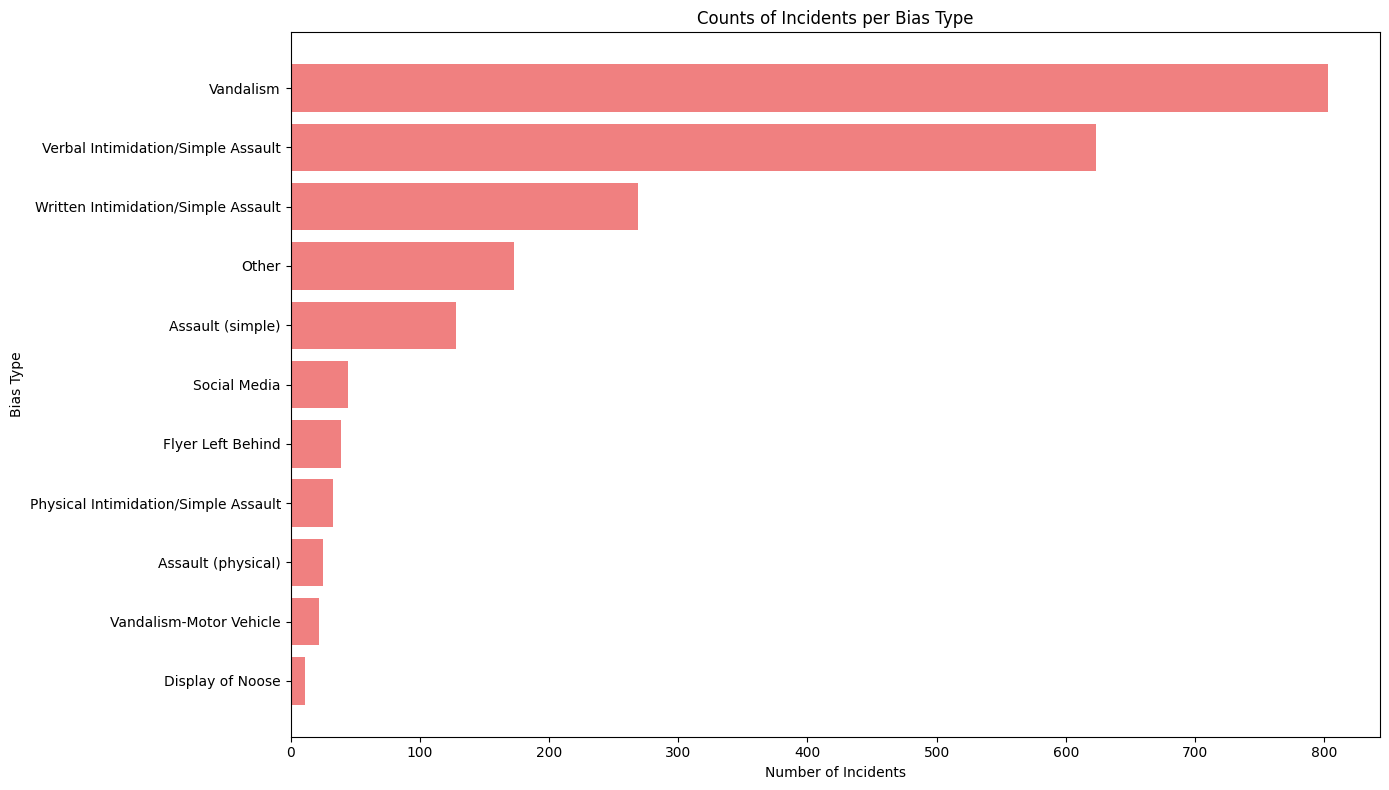

In [ ]:
bias_counts = {}

if data2:
    for item in data2:
        if 'bias' in item and item['bias']:
            bias = item['bias']
            bias_counts[bias] = bias_counts.get(bias, 0) + 1

    sorted_bias_counts = sorted(bias_counts.items(), key=lambda x: x[1], reverse=True)
    biases = [item[0] for item in sorted_bias_counts]
    counts = [item[1] for item in sorted_bias_counts]

    plt.figure(figsize=(14, 8))
    # Create horizontal bar chart
    plt.barh(biases[::-1], counts[::-1], color='lightcoral') # Reverse lists to have highest count at top
    plt.ylabel('Bias Type') # Y-axis now shows bias types
    plt.xlabel('Number of Incidents') # X-axis now shows incident counts
    plt.title('Counts of Incidents per Bias Type')
    os.makedirs("graphs", exist_ok=True)
    plt.yticks(rotation=0) # No rotation needed for y-axis labels
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Bias Type - Horizontal Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count bias types.")

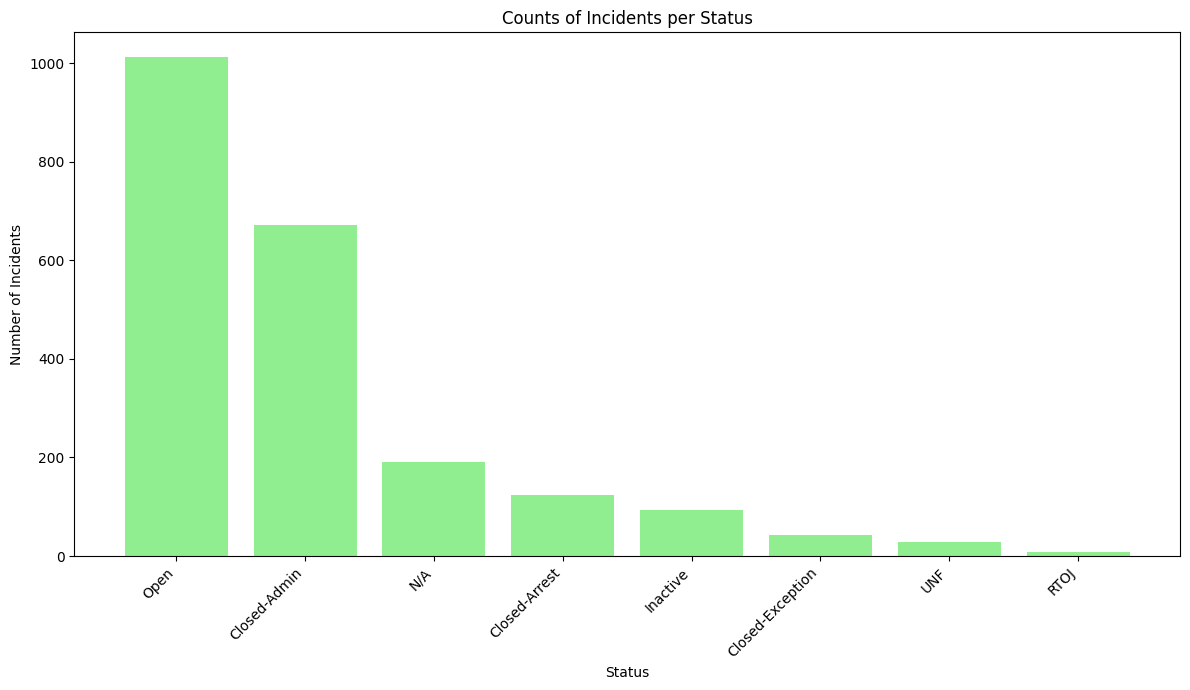

In [ ]:
status_counts = {}

if data2:
    for item in data2:
        if 'status' in item and item['status']:
            status = item['status']
            status_counts[status] = status_counts.get(status, 0) + 1

    sorted_status_counts = sorted(status_counts.items(), key=lambda x: x[1], reverse=True)
    statuses = [item[0] for item in sorted_status_counts]
    counts = [item[1] for item in sorted_status_counts]

    plt.figure(figsize=(12, 7))
    plt.bar(statuses, counts, color='lightgreen')
    plt.xlabel('Status')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Status')
    os.makedirs("graphs", exist_ok=True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Status - Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count statuses.")

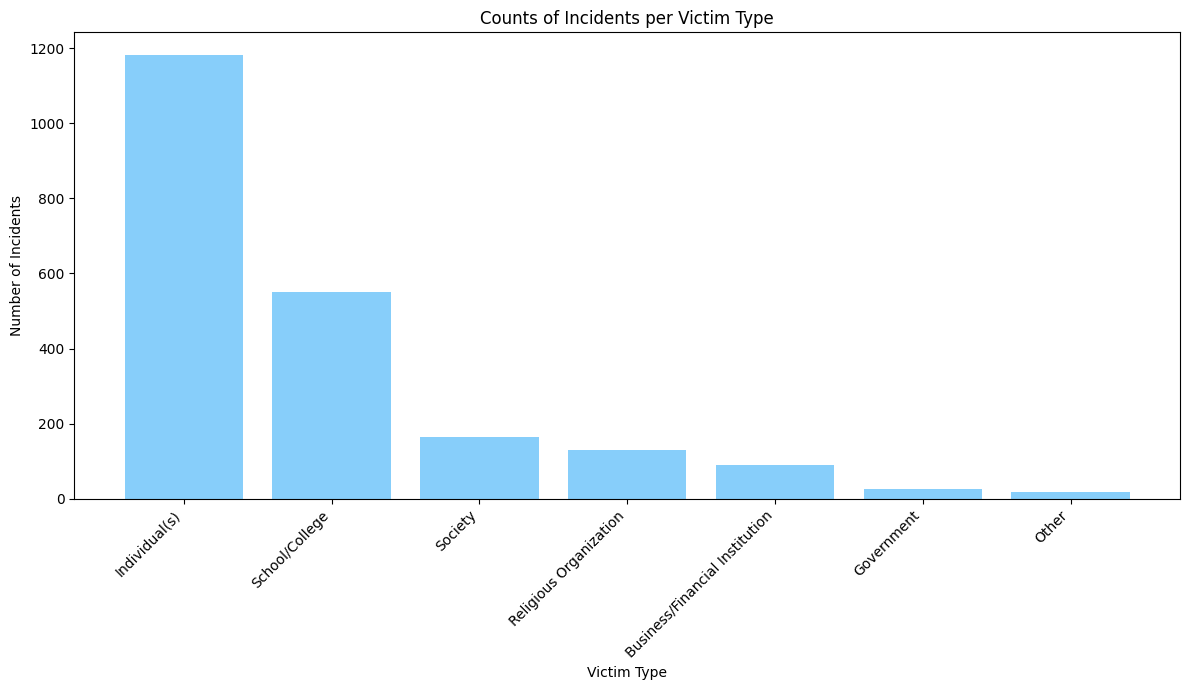

In [ ]:
victim_type_counts = {}

if data2:
    for item in data2:
        if 'victim_type' in item and item['victim_type']:
            victim_type = item['victim_type']
            victim_type_counts[victim_type] = victim_type_counts.get(victim_type, 0) + 1

    sorted_victim_type_counts = sorted(victim_type_counts.items(), key=lambda x: x[1], reverse=True)
    victim_types = [item[0] for item in sorted_victim_type_counts]
    counts = [item[1] for item in sorted_victim_type_counts]

    plt.figure(figsize=(12, 7))
    plt.bar(victim_types, counts, color='lightskyblue')
    plt.xlabel('Victim Type')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Victim Type')
    os.makedirs("graphs", exist_ok=True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Victim Type - Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count victim types.")

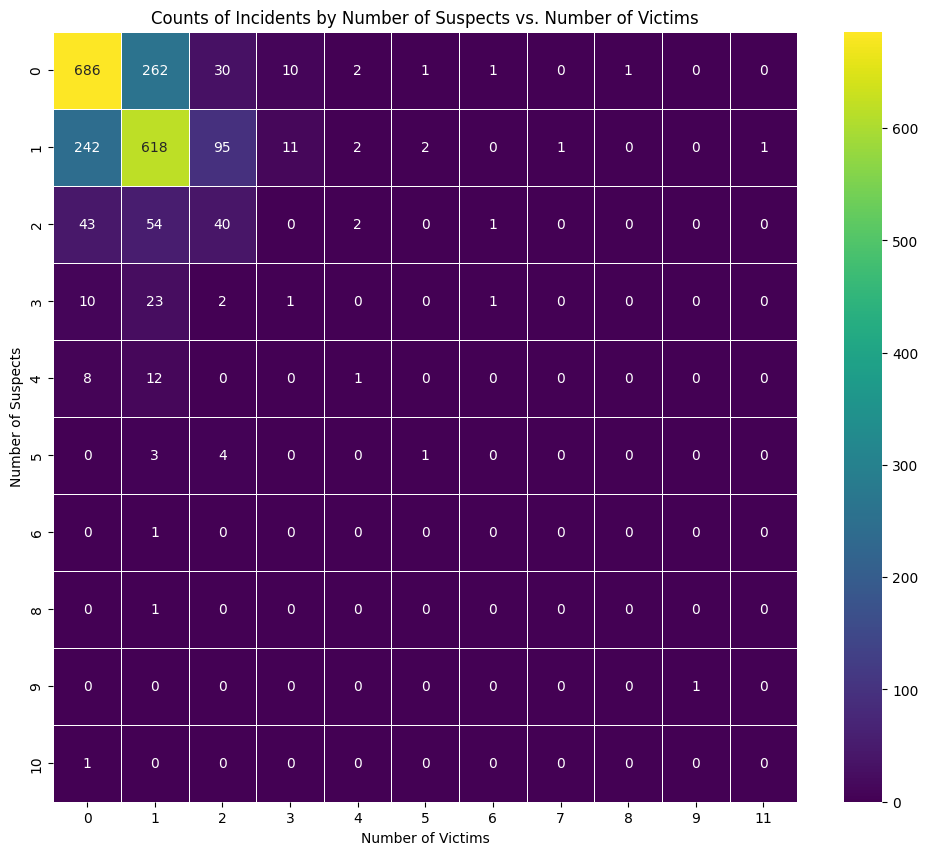

In [ ]:


# Create a DataFrame from the incident data
# Assuming data2 is already loaded and contains the incident information
incident_df = pd.DataFrame(data2)

# Convert 'no_of_suspects' and 'no_of_victims' to numeric
# Coerce errors to NaN, then fill NaN with 0 as requested for 'empty' values in a count context
incident_df['no_of_suspects'] = pd.to_numeric(incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)
incident_df['no_of_victims'] = pd.to_numeric(incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Calculate the counts of incidents for each combination of suspects and victims
counts_matrix = incident_df.groupby(['no_of_suspects', 'no_of_victims']).size().unstack(fill_value=0)

# Ensure all possible suspect/victim counts are covered in the index/columns if needed for consistency
# For example, if max suspects is 5 but 3 is missing, unstack might not create it. fill_value=0 handles this for the existing range.

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(counts_matrix, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Counts of Incidents by Number of Suspects vs. Number of Victims')
plt.xlabel('Number of Victims')
plt.ylabel('Number of Suspects')
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Suspects vs Victims Heatmap.png", bbox_inches="tight")
plt.show()

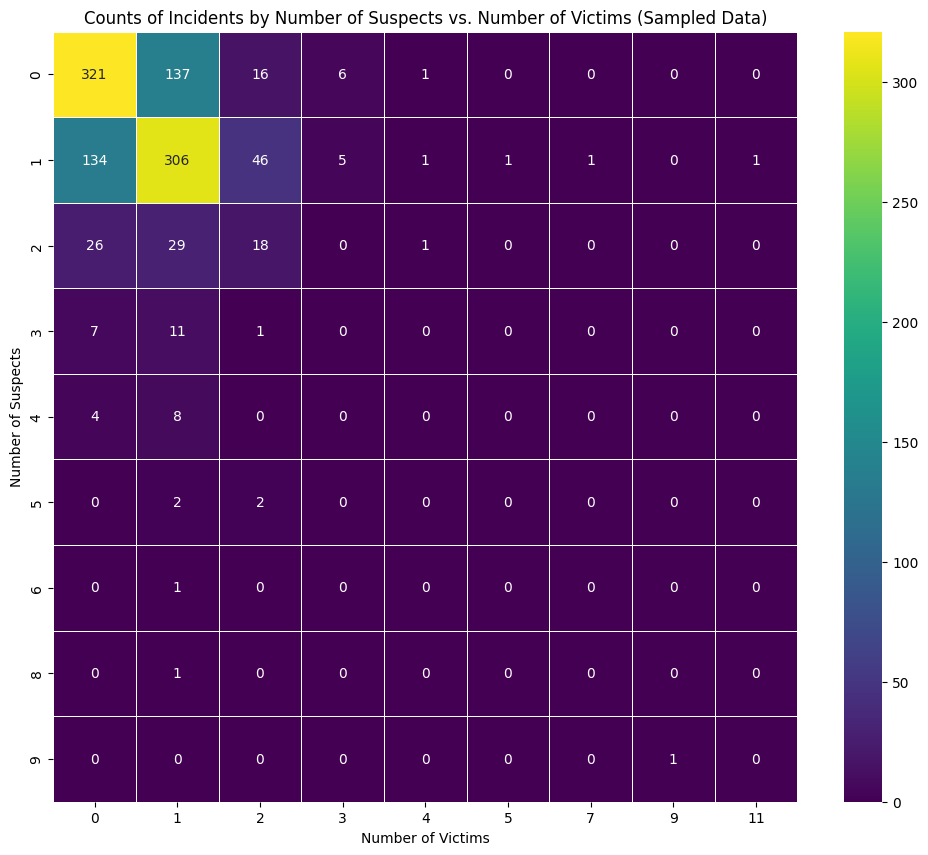

In [ ]:


# Take a sample of the incident_df
# Using a fraction of 0.5 (50% of the data) for the sample
sampled_incident_df = incident_df.sample(frac=0.5, random_state=42) # random_state for reproducibility

# Convert 'no_of_suspects' and 'no_of_victims' to numeric
sampled_incident_df['no_of_suspects'] = pd.to_numeric(sampled_incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)
sampled_incident_df['no_of_victims'] = pd.to_numeric(sampled_incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Calculate the counts of incidents for each combination of suspects and victims in the sample
sampled_counts_matrix = sampled_incident_df.groupby(['no_of_suspects', 'no_of_victims']).size().unstack(fill_value=0)

# Create the heatmap for the sampled data
plt.figure(figsize=(12, 10))
sns.heatmap(sampled_counts_matrix, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Counts of Incidents by Number of Suspects vs. Number of Victims (Sampled Data)')
plt.xlabel('Number of Victims')
plt.ylabel('Number of Suspects')
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Suspects vs Victims Heatmap_Sampled.png", bbox_inches="tight")
plt.show()

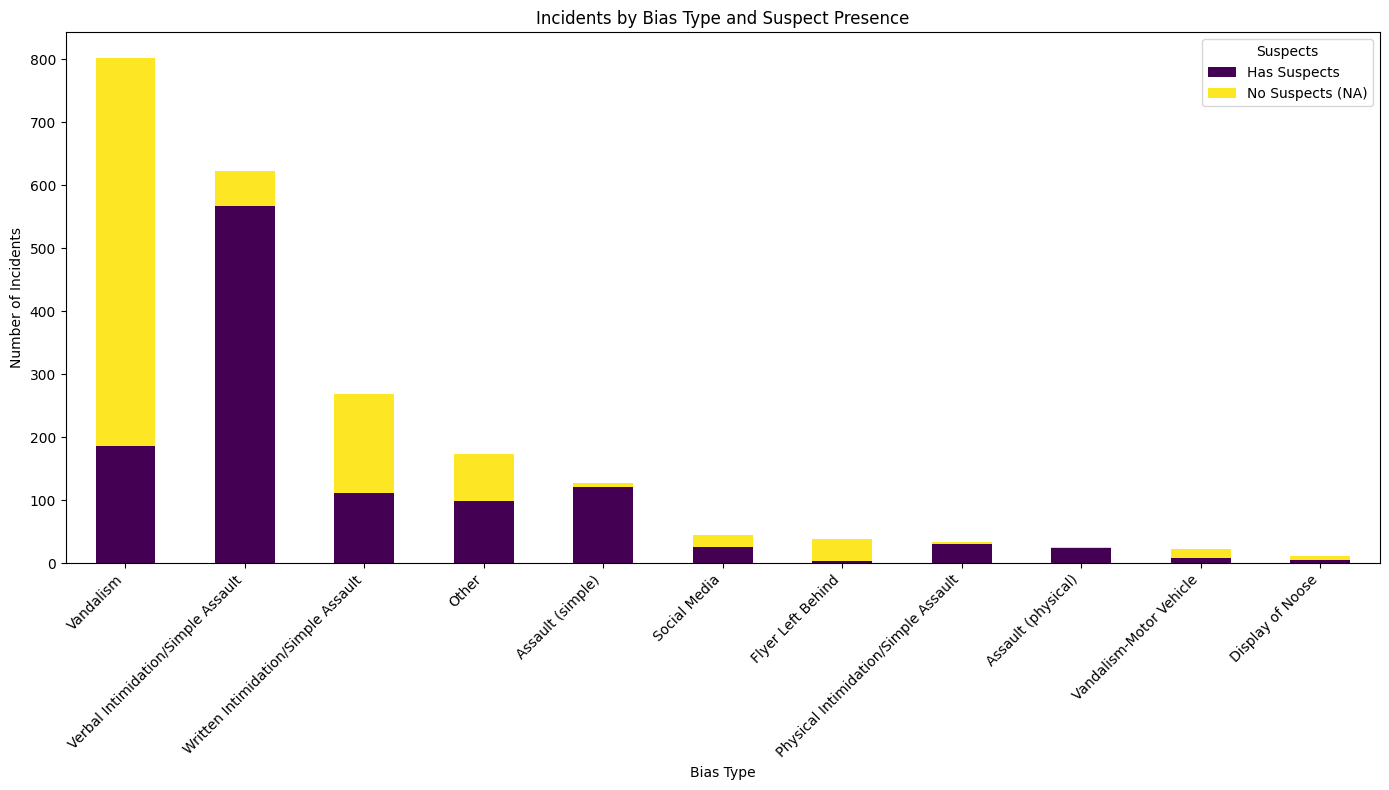

In [ ]:


# Ensure incident_df is available from previous steps
# If not, recreate it:
# incident_df = pd.DataFrame(data2)
# incident_df['no_of_suspects'] = pd.to_numeric(incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)

# Create a new column to categorize incidents based on 'no_of_suspects'
incident_df['suspect_presence'] = incident_df['no_of_suspects'].apply(lambda x: 'No Suspects (NA)' if x == 0 else 'Has Suspects')

# Group by 'bias' and 'suspect_presence' to get counts
bias_suspect_counts = incident_df.groupby(['bias', 'suspect_presence']).size().unstack(fill_value=0)

# Sort biases by total incident count for better visualization
bias_order = bias_suspect_counts.sum(axis=1).sort_values(ascending=False).index
bias_suspect_counts = bias_suspect_counts.loc[bias_order]

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))
bias_suspect_counts.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())

plt.title('Incidents by Bias Type and Suspect Presence')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Suspects')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Type and Suspect Presence - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()

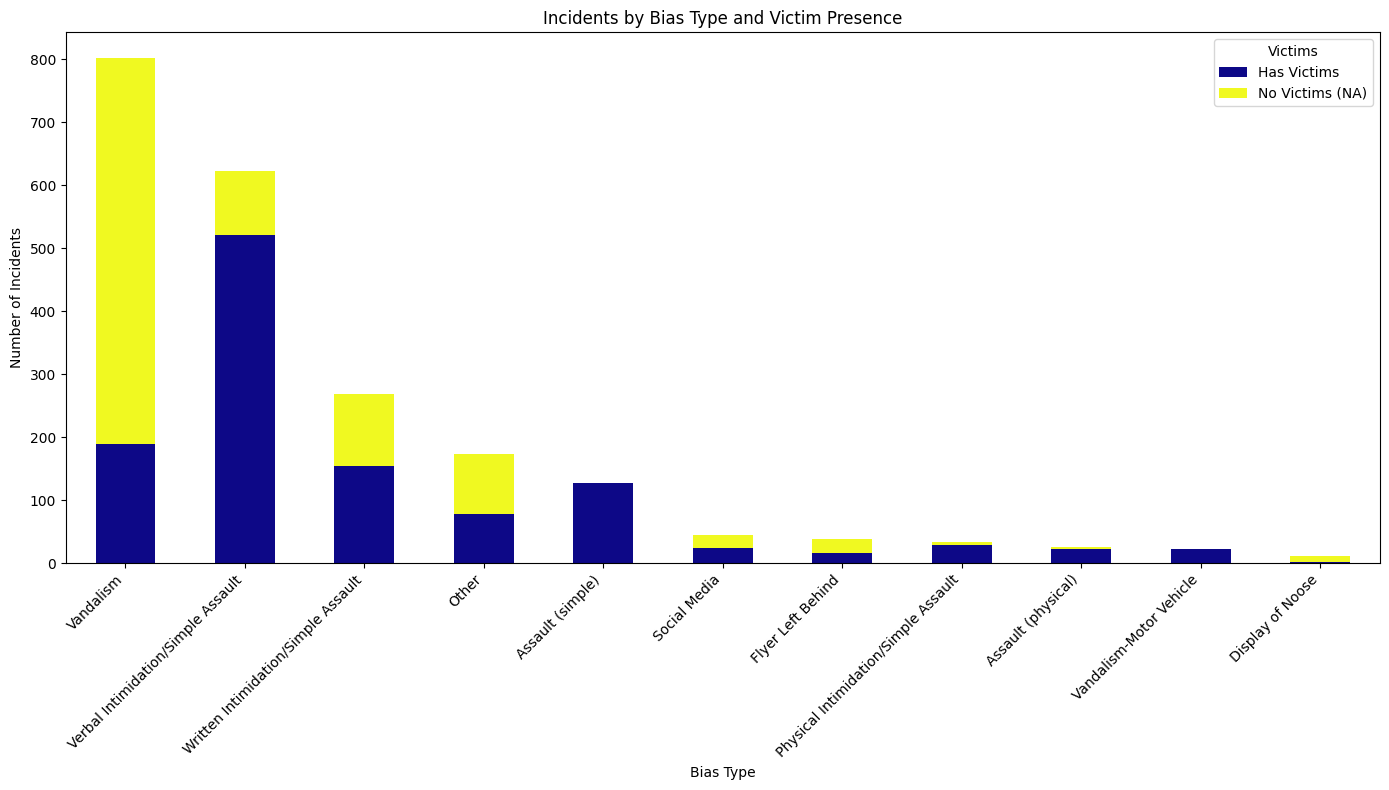

In [ ]:


# Ensure incident_df is available from previous steps
# If not, recreate it:
# incident_df = pd.DataFrame(data2)
# incident_df['no_of_victims'] = pd.to_numeric(incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Create a new column to categorize incidents based on 'no_of_victims'
incident_df['victim_presence'] = incident_df['no_of_victims'].apply(lambda x: 'No Victims (NA)' if x == 0 else 'Has Victims')

# Group by 'bias' and 'victim_presence' to get counts
bias_victim_presence_counts = incident_df.groupby(['bias', 'victim_presence']).size().unstack(fill_value=0)

# Sort biases by total incident count for better visualization
bias_order = bias_victim_presence_counts.sum(axis=1).sort_values(ascending=False).index
bias_victim_presence_counts = bias_victim_presence_counts.loc[bias_order]

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))
bias_victim_presence_counts.plot(kind='bar', stacked=True, cmap='plasma', ax=plt.gca())

plt.title('Incidents by Bias Type and Victim Presence')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Victims')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Type and Victim Presence - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()


### Incidents per Police District

Let's visualize the number of incidents reported in each police district to understand the geographical distribution of bias incidents.

/tmp/ipykernel_10525/4206871090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_counts.index, y=district_counts.values, palette='viridis')


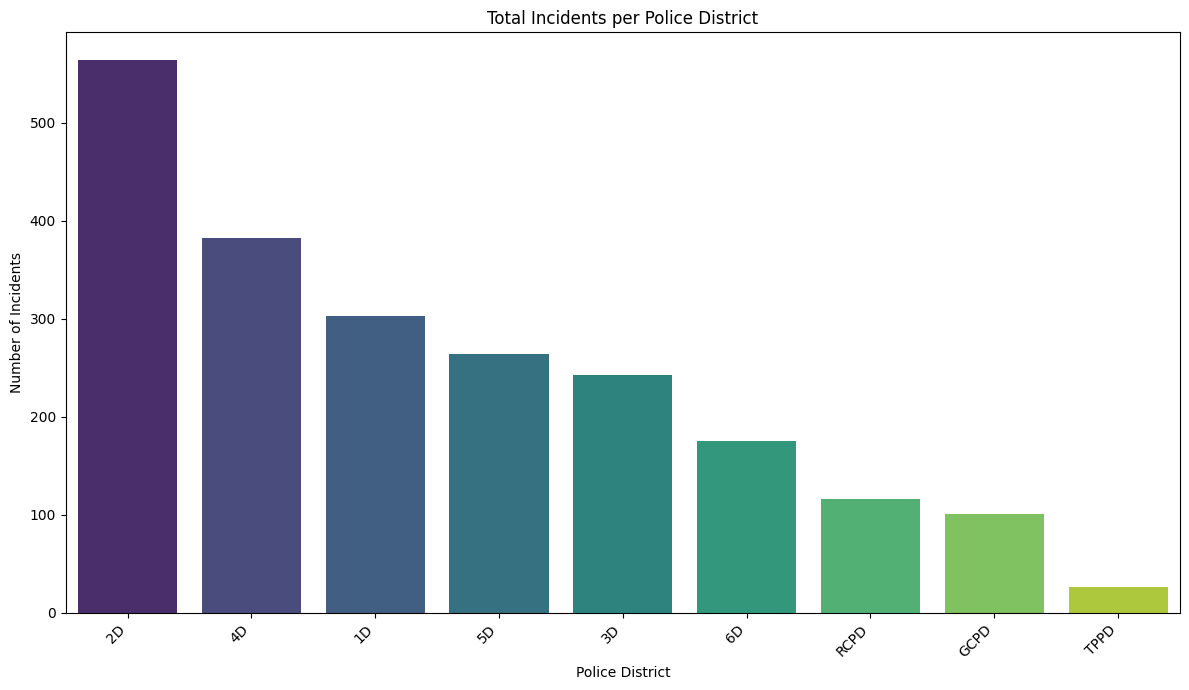

In [ ]:
district_counts = incident_df['district'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=district_counts.index, y=district_counts.values, palette='viridis')
plt.title('Total Incidents per Police District')
plt.xlabel('Police District')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Incidents per Police District - Bar Chart.png", bbox_inches="tight")
plt.show()

### Bias Types by Police District

Now, let's explore which bias types are most prevalent in each police district using a stacked bar chart.

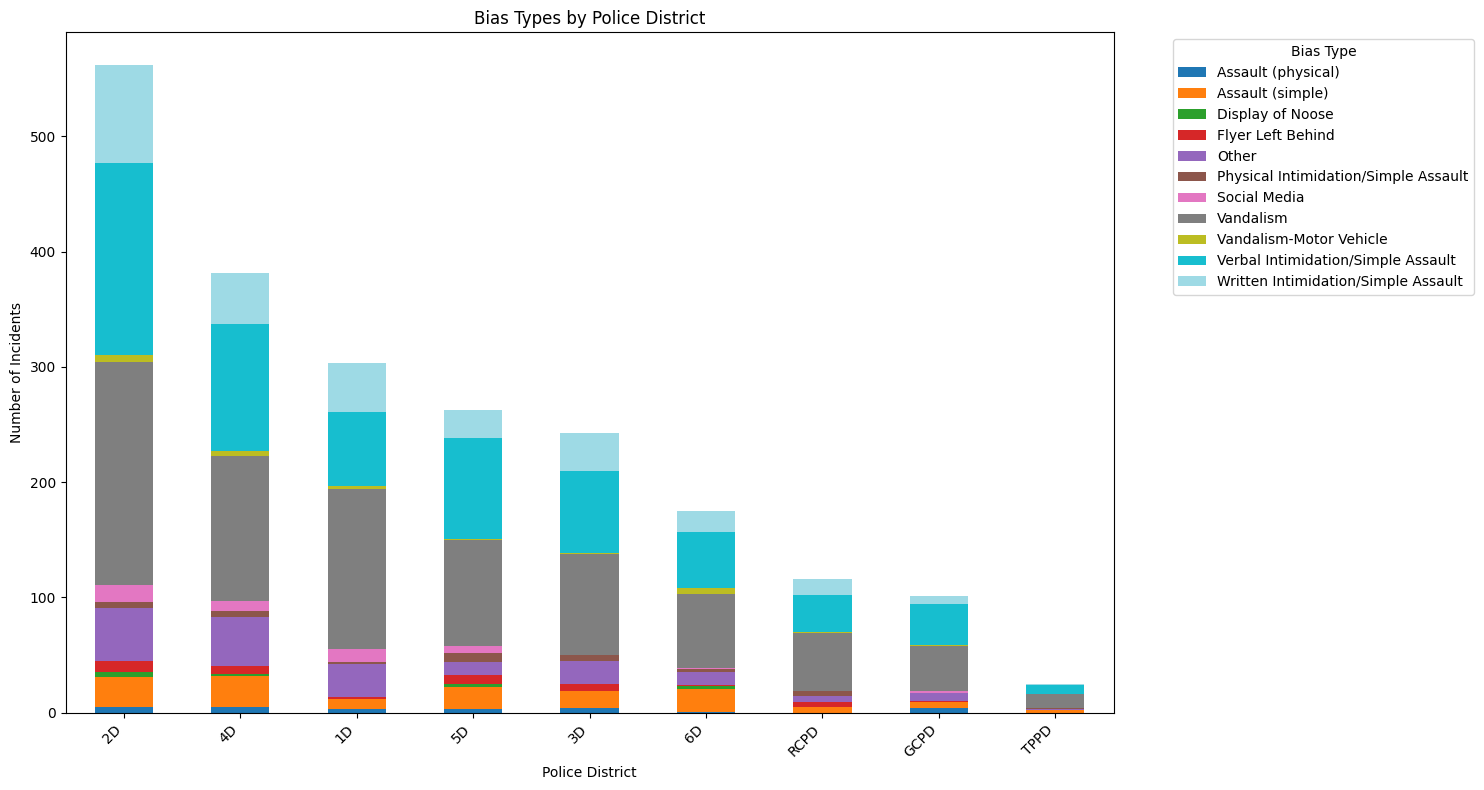

In [ ]:
district_bias_counts = incident_df.groupby(['district', 'bias']).size().unstack(fill_value=0)

# Sort districts by total incidents for better visualization
district_order = district_bias_counts.sum(axis=1).sort_values(ascending=False).index
district_bias_counts = district_bias_counts.loc[district_order]

plt.figure(figsize=(15, 8))
district_bias_counts.plot(kind='bar', stacked=True, cmap='tab20', ax=plt.gca())
plt.title('Bias Types by Police District')
plt.xlabel('Police District')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Bias Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Types by Police District - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()

### Victim Type vs. Bias Type

This visualization will show the relationship between the type of bias and the type of victim involved in the incidents.

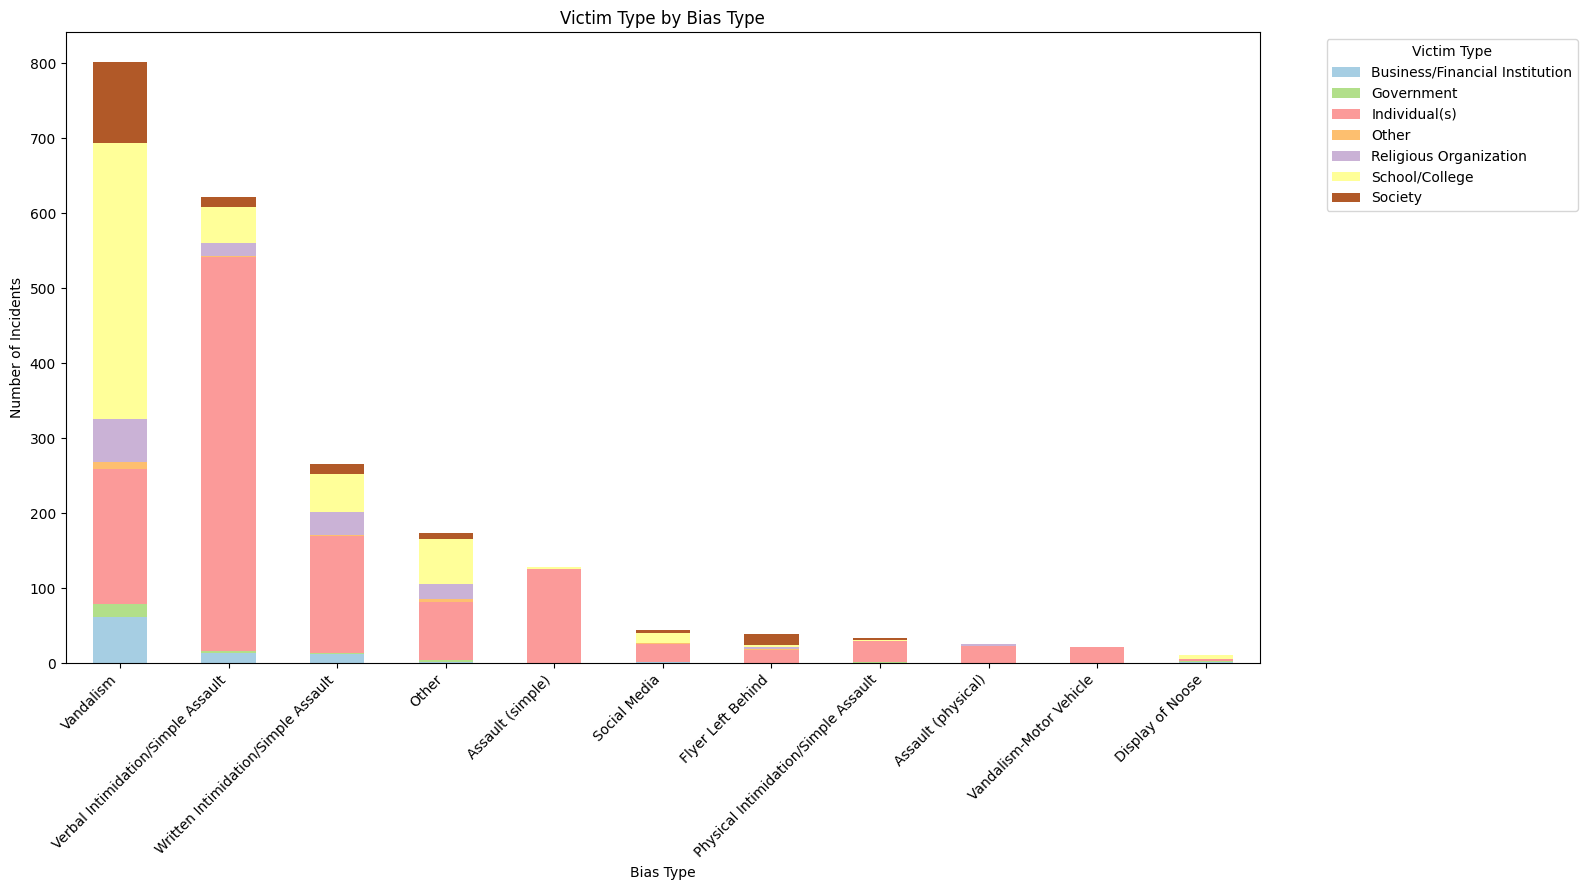

In [ ]:
bias_victim_type_counts = incident_df.groupby(['bias', 'victim_type']).size().unstack(fill_value=0)

# Sort biases by total incident count
bias_order_victim_type = bias_victim_type_counts.sum(axis=1).sort_values(ascending=False).index
bias_victim_type_counts = bias_victim_type_counts.loc[bias_order_victim_type]

plt.figure(figsize=(16, 9))
bias_victim_type_counts.plot(kind='bar', stacked=True, cmap='Paired', ax=plt.gca())
plt.title('Victim Type by Bias Type')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Victim Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Victim Type by Bias Type - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()

### Contextualizing African American Population with 'Anti-Black' Bias Incidents

Let's put the African American population from the Census data into context with the number of 'Anti-Black' bias incidents reported.

In [ ]:
print(f"African American population in {county_name}: {african_american_population}")

anti_black_incidents = incident_df[incident_df['bias_code'] == 'Anti-Black'].shape[0]
print(f"Total 'Anti-Black' bias incidents reported in Montgomery County: {anti_black_incidents}")

African American population in Montgomery County, Maryland: 198264
Total 'Anti-Black' bias incidents reported in Montgomery County: 691


In [ ]:
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os

# Police district information from the user's prompt
police_districts_info = {
    "1st District (Rockville)": "100 Edison Park Drive, Gaithersburg, MD 20878",
    "2nd District (Bethesda)": "4823 Rugby Avenue, Bethesda, MD 20814",
    "3rd District (Silver Spring)": "1002 Milestone Dr, Silver Spring, MD 20904",
    "4th District (Wheaton)": "2300 Randolph Road, Wheaton, MD 20902",
    "5th District (Germantown)": "20000 Aircraft Drive, Germantown, MD 20874",
    "6th District (Montgomery Village/Gaithersburg)": "222 Paramount Park Drive, Gaithersburg, MD 20879"
}

# Initialize Nominatim geocoder
geolocator = Nominatim(user_agent="montgomery_county_police_map")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Geocode addresses and store coordinates
geocoded_districts = {}
for name, address in police_districts_info.items():
    try:
        location = geocode(address)
        if location:
            geocoded_districts[name] = {'address': address, 'latitude': location.latitude, 'longitude': location.longitude}
            print(f"Geocoded {name}: {location.latitude}, {location.longitude}")
        else:
            print(f"Could not geocode address for {name}: {address}")
    except Exception as e:
        print(f"Error geocoding {name} ({address}): {e}")

# Create a Folium map centered around Montgomery County, MD
# (Approximate coordinates for Montgomery County center)
m = folium.Map(location=[39.15, -77.25], zoom_start=10)

# Add markers for each geocoded police district
for name, info in geocoded_districts.items():
    folium.Marker(
        location=[info['latitude'], info['longitude']],
        popup=f"<b>{name}</b><br>{info['address']}",
        tooltip=name
    ).add_to(m)

# Create the graphs directory if it doesn't exist
os.makedirs("graphs", exist_ok=True)

# Save the map to an HTML file
map_path = "graphs/Montgomery_County_Police_Districts_Map.html"
m.save(map_path)

print(f"Interactive map saved to {map_path}")
print("Please open the HTML file in your browser to view the map.")


Geocoded 1st District (Rockville): 39.1130124, -77.2361046
Geocoded 2nd District (Bethesda): 38.9913653, -77.0978593
Geocoded 3rd District (Silver Spring): 39.0453364, -76.9907551
Geocoded 4th District (Wheaton): 39.0589915, -77.0642287
Geocoded 5th District (Germantown): 39.1844222, -77.2626995
Geocoded 6th District (Montgomery Village/Gaithersburg): 39.1604419, -77.2209785
Interactive map saved to graphs/Montgomery_County_Police_Districts_Map.html
Please open the HTML file in your browser to view the map.
